In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf

In [20]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

In [21]:
df_train = pd.read_csv('data/MR_number_train_0w-5w.csv.zip', index_col=0)
df_test = pd.read_csv('data/MR_number_test_5w-6w.csv.zip', index_col=0)

In [22]:
print(f"Train set shape: {df_train.shape}")
print(f"{df_train.shape[0]} временных шагов")
print(f"{df_train.shape[1]} лучей (beams)")
print(f"Test set shape: {df_test.shape}")

Train set shape: (840, 2880)
840 временных шагов
2880 лучей (beams)
Test set shape: (168, 2880)


In [23]:
# Парсим названия колонок (лучей)
# Формат: base_station_cell_beam
beam_metadata = pd.DataFrame({
    'beam_id': df_train.columns
})

Извлекаем метаданные

In [24]:
beam_metadata[['base_station', 'cell', 'beam']] = beam_metadata['beam_id'].str.split('_', expand=True)
beam_metadata['base_station'] = beam_metadata['base_station'].astype(int)
beam_metadata['cell'] = beam_metadata['cell'].astype(int)
beam_metadata['beam'] = beam_metadata['beam'].astype(int)

In [25]:
print(f"Базовых станций: {beam_metadata['base_station'].nunique()}")
print(f"Диапазон: {beam_metadata['base_station'].min()} - {beam_metadata['base_station'].max()}")
print(f"Сот на станцию: {beam_metadata.groupby('base_station')['cell'].nunique().iloc[0]}")
print(f"Лучей на соту: {beam_metadata.groupby(['base_station','cell'])['beam'].nunique().iloc[0]}")
print(f"Итого лучей: {len(beam_metadata)}")

Базовых станций: 30
Диапазон: 0 - 29
Сот на станцию: 3
Лучей на соту: 32
Итого лучей: 2880


Статистика распределений

In [26]:
# Общая статистика по всем лучам
all_values = df_train.values.flatten()
all_values = all_values[~np.isnan(all_values)]

print("Глобальная статистика (все лучи, все время):")
print(f"Среднее: {np.mean(all_values):.4f}")
print(f"Медиана: {np.median(all_values):.4f}")
print(f"Std: {np.std(all_values):.4f}")
print(f"Min: {np.min(all_values):.4f}")
print(f"1-й перцентиль: {np.percentile(all_values, 1):.4f}")
print(f"99-й перцентиль: {np.percentile(all_values, 99):.4f}")
print(f"Max: {np.max(all_values):.4f}")

Глобальная статистика (все лучи, все время):
Среднее: 0.6024
Медиана: 0.2273
Std: 1.0486
Min: 0.0000
1-й перцентиль: 0.0000
99-й перцентиль: 5.0658
Max: 33.6660


Статистика по каждому лучу

In [27]:
beam_means = df_train.mean()
beam_medians = df_train.median()
beam_stds = df_train.std()
beam_zeros = (df_train == 0).sum() / len(df_train) * 100  # процент нулей

print("Статистика по лучам (mean across time):")
print(f"Среднее средних: {beam_means.mean():.4f} ± {beam_means.std():.4f}")
print(f"Среднее медиан: {beam_medians.mean():.4f} ± {beam_medians.std():.4f}")
print(f"Среднее std: {beam_stds.mean():.4f} ± {beam_stds.std():.4f}")
print(f"Средний % нулей: {beam_zeros.mean():.1f}% ± {beam_zeros.std():.1f}%")

Статистика по лучам (mean across time):
Среднее средних: 0.6024 ± 0.8274
Среднее медиан: 0.5325 ± 0.8187
Среднее std: 0.4240 ± 0.4858
Средний % нулей: 20.2% ± 16.3%


Вычисляем SNR и CV

In [28]:
signal_to_noise = beam_means / (beam_stds + 1e-8)  # добавляем epsilon чтобы избежать деления на 0
cv = beam_stds / (beam_means + 1e-8)  # коэффициент вариации

print("Signal-to-Noise Ratio (Mean/Std):")
print(f"Средний SNR: {signal_to_noise.mean():.3f}")
print(f"Медианный SNR: {signal_to_noise.median():.3f}")
print(f"Min SNR: {signal_to_noise.min():.3f}")
print(f"Max SNR: {signal_to_noise.max():.3f}")

print("Коэффициент вариации (Std/Mean):")
print(f"Средний CV: {cv.mean():.3f}")
print(f"Медианный CV: {cv.median():.3f}")
print(f"{'Низкая' if cv.median() < 0.5 else 'Средняя' if cv.median() < 1 else 'Высокая'} волатильность")

Signal-to-Noise Ratio (Mean/Std):
Средний SNR: 1.178
Медианный SNR: 1.031
Min SNR: 0.420
Max SNR: 3.998
Коэффициент вариации (Std/Mean):
Средний CV: 0.976
Медианный CV: 0.970
Средняя волатильность


Находим самые активные и неактивные лучи

In [29]:
top_active = beam_means.nlargest(5)
top_inactive = beam_means.nsmallest(5)

print("Топ-5 самых активных лучей (средний user count):")
for beam, val in top_active.items():
    print(f"{beam}: {val:.2f}")

print("Топ-5 самых неактивных лучей (средний user count):")
for beam, val in top_inactive.items():
    print(f"{beam}: {val:.2f}")

Топ-5 самых активных лучей (средний user count):
24_0_17: 8.00
8_0_21: 6.79
22_2_13: 6.42
23_1_21: 6.37
19_2_15: 5.90
Топ-5 самых неактивных лучей (средний user count):
5_0_23: 0.05
28_1_31: 0.05
26_2_25: 0.05
23_1_0: 0.06
5_2_7: 0.06


Находим луч, наиболее близкий к медиане

In [30]:
median_value = beam_means.quantile(0.5)
median_beam_idx = (beam_means - median_value).abs().idxmin()
median_beam = median_beam_idx

print(f"Медианный луч (наиболее типичный): {median_beam}")
print(f"Среднее значение: {beam_means[median_beam]:.4f}")

Медианный луч (наиболее типичный): 4_2_29
Среднее значение: 0.2773


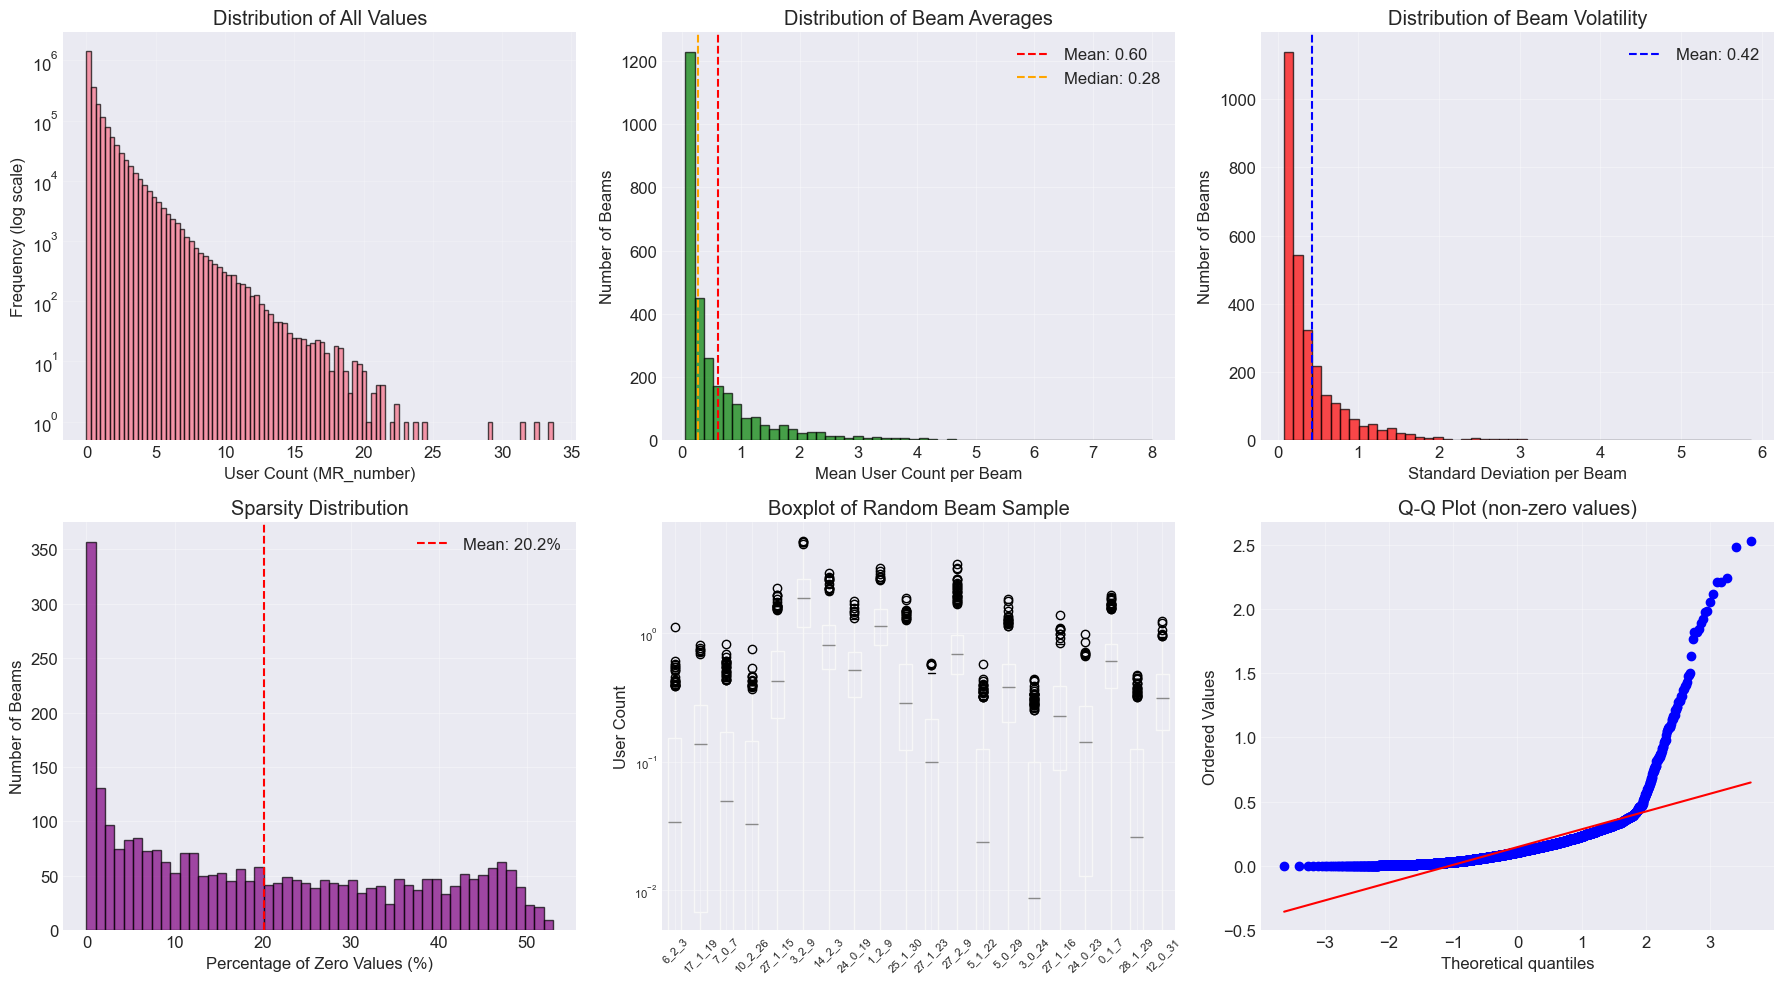

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Гистограмма всех значений
axes[0,0].hist(all_values, bins=100, alpha=0.7, edgecolor='black', log=True)
axes[0,0].set_xlabel('User Count (MR_number)')
axes[0,0].set_ylabel('Frequency (log scale)')
axes[0,0].set_title('Distribution of All Values')
axes[0,0].grid(True, alpha=0.3)

# Распределение средних по лучам
axes[0,1].hist(beam_means, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0,1].set_xlabel('Mean User Count per Beam')
axes[0,1].set_ylabel('Number of Beams')
axes[0,1].set_title('Distribution of Beam Averages')
axes[0,1].axvline(beam_means.mean(), color='red', linestyle='--', label=f'Mean: {beam_means.mean():.2f}')
axes[0,1].axvline(beam_means.median(), color='orange', linestyle='--', label=f'Median: {beam_means.median():.2f}')
axes[0,1].legend()

# Распределение std по лучам
axes[0,2].hist(beam_stds, bins=50, alpha=0.7, edgecolor='black', color='red')
axes[0,2].set_xlabel('Standard Deviation per Beam')
axes[0,2].set_ylabel('Number of Beams')
axes[0,2].set_title('Distribution of Beam Volatility')
axes[0,2].axvline(beam_stds.mean(), color='blue', linestyle='--', label=f'Mean: {beam_stds.mean():.2f}')
axes[0,2].legend()

# Процент нулей по лучам
axes[1,0].hist(beam_zeros, bins=50, alpha=0.7, edgecolor='black', color='purple')
axes[1,0].set_xlabel('Percentage of Zero Values (%)')
axes[1,0].set_ylabel('Number of Beams')
axes[1,0].set_title('Sparsity Distribution')
axes[1,0].axvline(beam_zeros.mean(), color='red', linestyle='--', label=f'Mean: {beam_zeros.mean():.1f}%')
axes[1,0].legend()

# Boxplot выборки лучей
sample_beams = np.random.choice(df_train.columns, min(20, len(df_train.columns)), replace=False)
sample_data = df_train[sample_beams]
sample_data.boxplot(ax=axes[1,1], rot=45, fontsize=8)
axes[1,1].set_title('Boxplot of Random Beam Sample')
axes[1,1].set_ylabel('User Count')
axes[1,1].set_yscale('log')

# QQ-plot для проверки нормальности
# Берем семпл для QQ-plot (чтобы не перегружать)
sample_for_qq = all_values[all_values > 0][:5000] if len(all_values[all_values > 0]) > 5000 else all_values[all_values > 0]
if len(sample_for_qq) > 0:
    stats.probplot(sample_for_qq, dist="norm", plot=axes[1,2])
    axes[1,2].set_title('Q-Q Plot (non-zero values)')
else:
    axes[1,2].text(0.5, 0.5, 'No non-zero values', ha='center', va='center')
    axes[1,2].set_title('Q-Q Plot - Insufficient data')

plt.tight_layout()
plt.show()

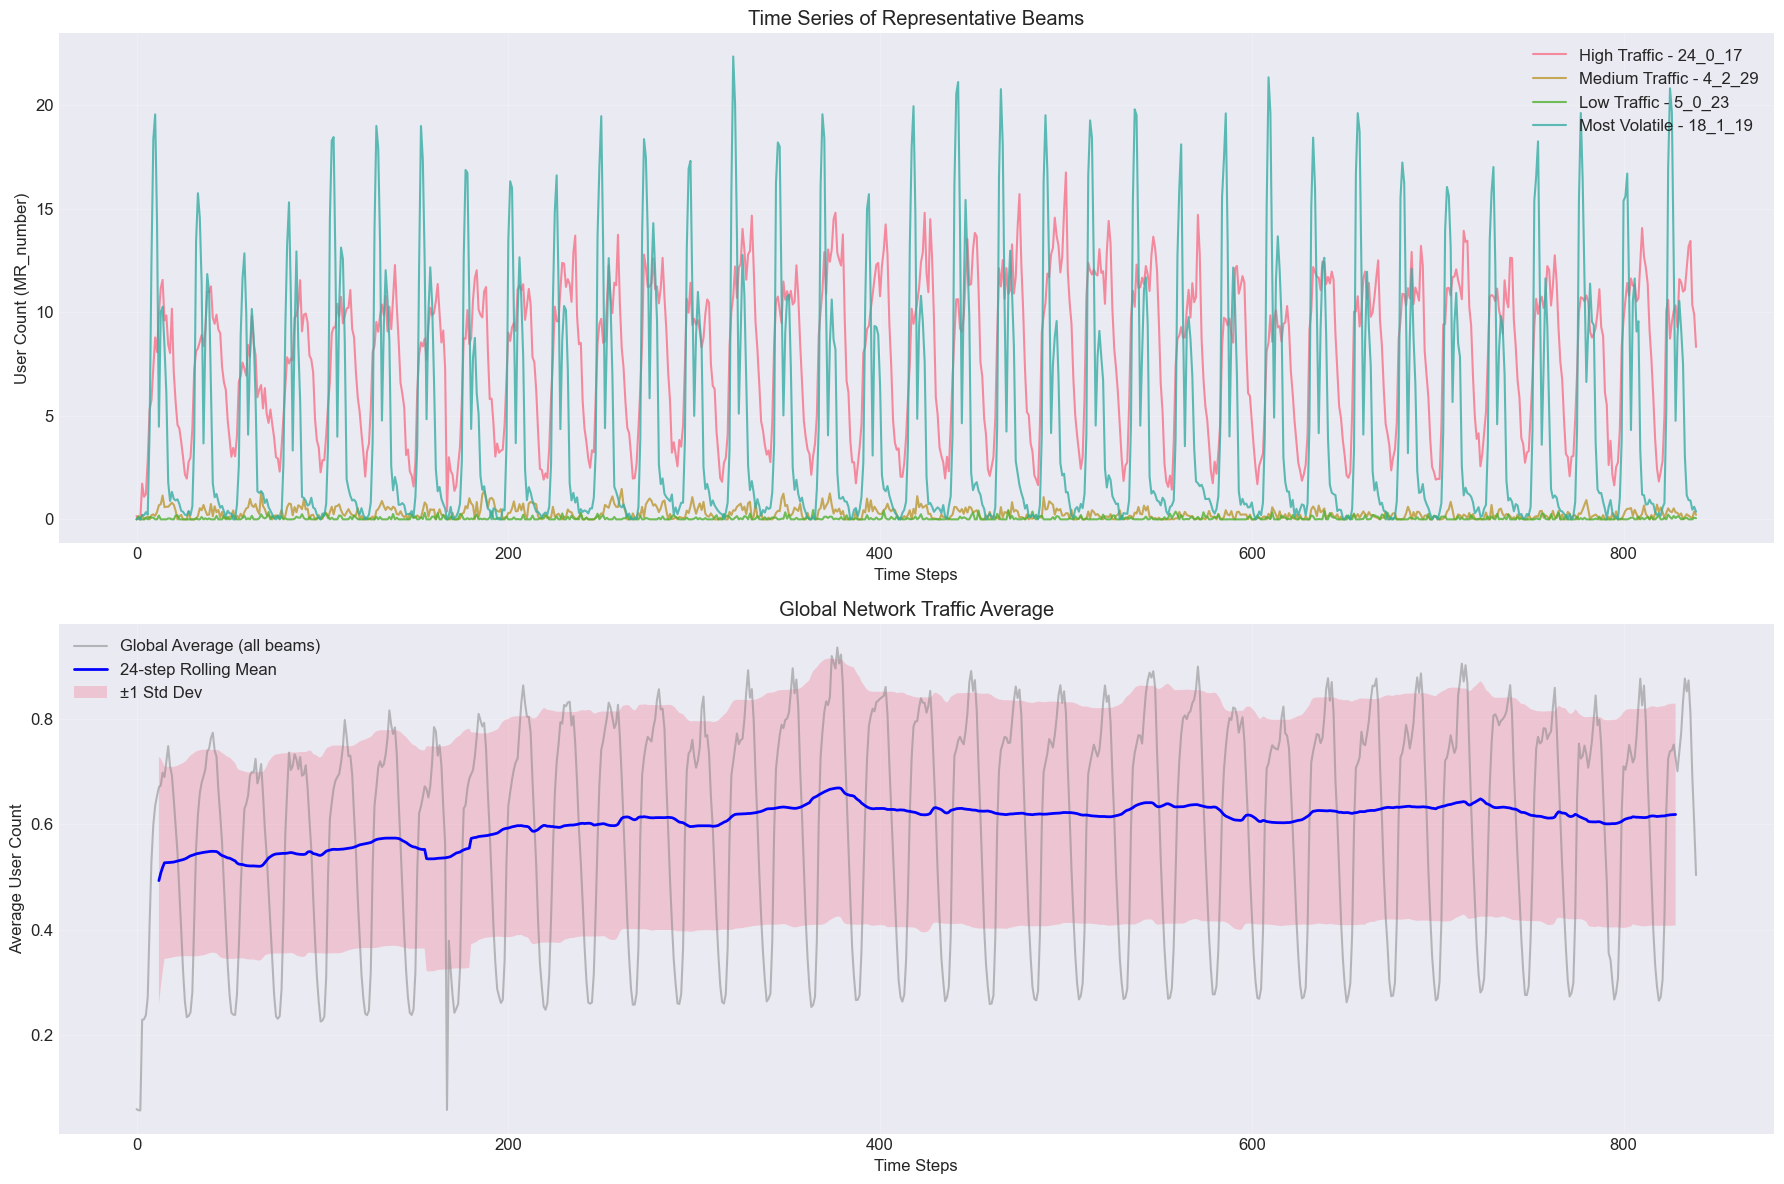

In [32]:
representative_beams = {}

# Добавляем лучи, если они существуют
if len(top_active) > 0:
    representative_beams['High Traffic'] = top_active.index[0]
if median_beam:
    representative_beams['Medium Traffic'] = median_beam
if len(top_inactive) > 0:
    representative_beams['Low Traffic'] = top_inactive.index[0]
if len(beam_stds.nlargest(1)) > 0:
    representative_beams['Most Volatile'] = beam_stds.nlargest(1).index[0]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Временные ряды
if len(representative_beams) > 0:
    for name, beam in representative_beams.items():
        axes[0].plot(range(len(df_train)), df_train[beam], label=f'{name} - {beam}', alpha=0.8, linewidth=1.5)
else:
    axes[0].text(0.5, 0.5, 'No representative beams found', ha='center', va='center')

axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('User Count (MR_number)')
axes[0].set_title('Time Series of Representative Beams')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Среднее по всем лучам + доверительный интервал
daily_avg = df_train.mean(axis=1)
rolling_mean = daily_avg.rolling(window=min(24, len(daily_avg)//4), center=True).mean()
rolling_std = daily_avg.rolling(window=min(24, len(daily_avg)//4), center=True).std()

axes[1].plot(daily_avg, alpha=0.5, label='Global Average (all beams)', color='gray')
axes[1].plot(rolling_mean, label=f'{min(24, len(daily_avg)//4)}-step Rolling Mean', color='blue', linewidth=2)
axes[1].fill_between(range(len(rolling_mean)),
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     alpha=0.3, label='±1 Std Dev')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Average User Count')
axes[1].set_title('Global Network Traffic Average')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

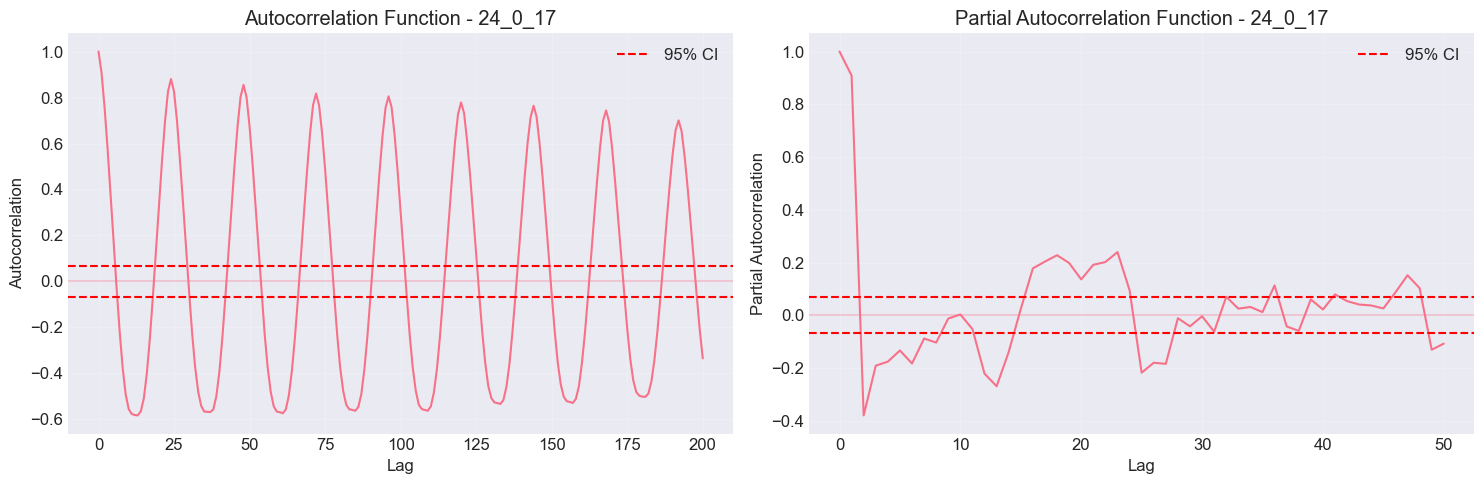

Автокорреляционный анализ луча 24_0_17:
Lag 24 correlation: 0.880
Lag 168 correlation: 0.744


In [33]:
if len(top_active) > 0:
    sample_beam = top_active.index[0]
    sample_series = df_train[sample_beam].dropna()
    if len(sample_series) > 10:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        # ACF
        max_lags = min(200, len(sample_series)//3)
        if max_lags > 0:
            acf_vals = acf(sample_series, nlags=max_lags, fft=True)
            axes[0].plot(acf_vals)
            axes[0].axhline(y=0, linestyle='-', alpha=0.3)
            axes[0].axhline(y=1.96/np.sqrt(len(sample_series)), linestyle='--', color='red', label='95% CI')
            axes[0].axhline(y=-1.96/np.sqrt(len(sample_series)), linestyle='--', color='red')
            axes[0].set_xlabel('Lag')
            axes[0].set_ylabel('Autocorrelation')
            axes[0].set_title(f'Autocorrelation Function - {sample_beam}')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            # PACF
            max_pacf_lags = min(50, len(sample_series)//10)
            if max_pacf_lags > 0:
                pacf_vals = pacf(sample_series, nlags=max_pacf_lags)
                axes[1].plot(pacf_vals)
                axes[1].axhline(y=0, linestyle='-', alpha=0.3)
                axes[1].axhline(y=1.96/np.sqrt(len(sample_series)), linestyle='--', color='red', label='95% CI')
                axes[1].axhline(y=-1.96/np.sqrt(len(sample_series)), linestyle='--', color='red')
                axes[1].set_xlabel('Lag')
                axes[1].set_ylabel('Partial Autocorrelation')
                axes[1].set_title(f'Partial Autocorrelation Function - {sample_beam}')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            print(f"Автокорреляционный анализ луча {sample_beam}:")
            if max_lags > 23:
                print(f"Lag 24 correlation: {acf_vals[24] if len(acf_vals) > 24 else 'N/A':.3f}")
            if max_lags > 167:
                print(f"Lag 168 correlation: {acf_vals[168] if len(acf_vals) > 168 else 'N/A':.3f}")
    else:
        print("Недостаточно данных для ACF анализа")
else:
    print("Нет активных лучей для анализа")

Найдена группа: Station 0, Cell 0 (32 лучей)


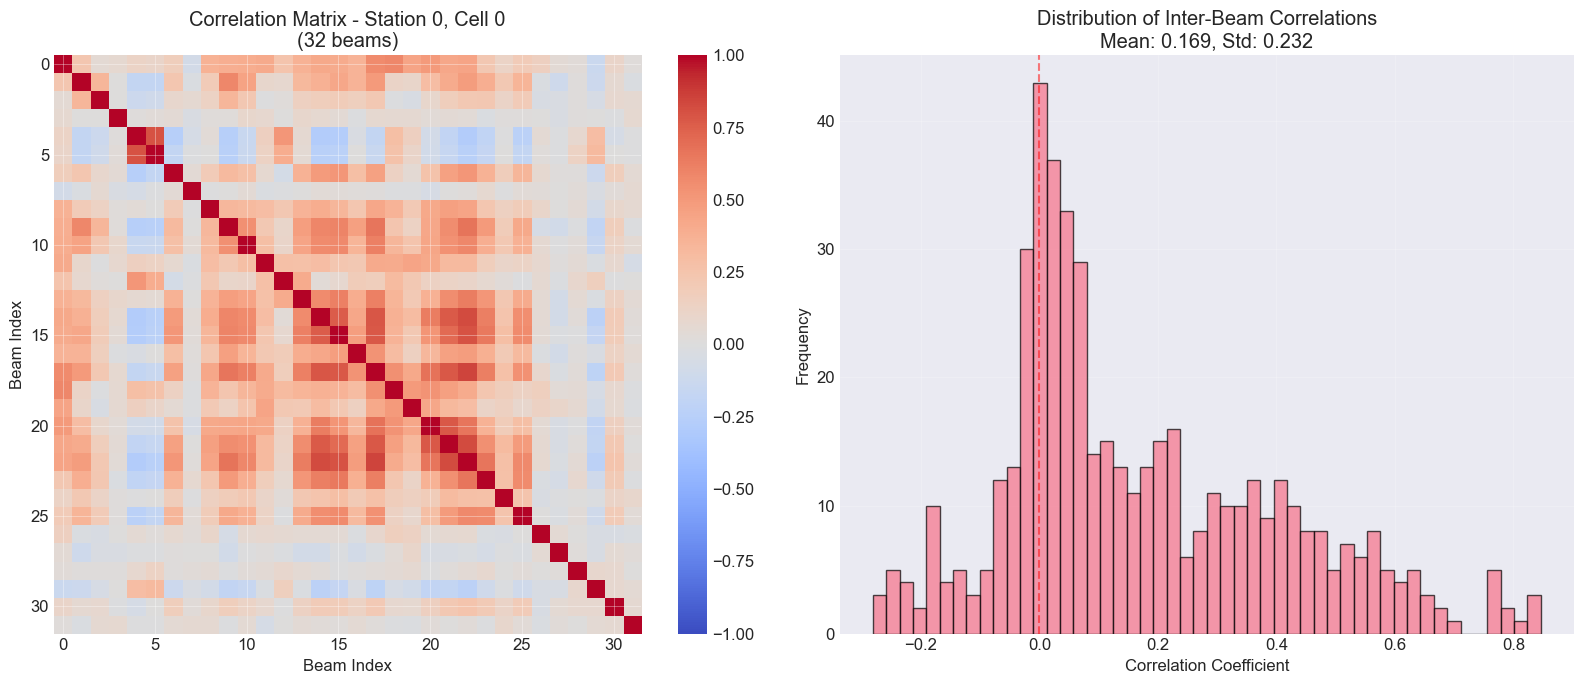

Статистика корреляций внутри соты:
Средняя корреляция: 0.1686
Медианная корреляция: 0.0934
Макс. корреляция: 0.8460
Мин. корреляция: -0.2807


In [34]:
# Ищем первую доступную группу лучей
found_group = False
for station in range(30):  # Пробуем первые 30 станций
    for cell in range(3):  # Пробуем первые 3 соты
        group_pattern = f'{station}_{cell}_'
        group_beams = [col for col in df_train.columns if col.startswith(group_pattern)]
        if len(group_beams) >= 5:  # Нашли группу с хотя бы 5 лучами
            found_group = True
            station_0_cell_0_beams = group_beams
            print(f"Найдена группа: Station {station}, Cell {cell} ({len(group_beams)} лучей)")
            break
    if found_group:
        break

if found_group and len(station_0_cell_0_beams) > 1:
    cell_data = df_train[station_0_cell_0_beams]
    correlation_matrix = cell_data.corr()
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    # Тепловая карта корреляций
    im = axes[0].imshow(correlation_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_title(f'Correlation Matrix - Station {station_0_cell_0_beams[0].split("_")[0]}, Cell {station_0_cell_0_beams[0].split("_")[1]}\n({len(station_0_cell_0_beams)} beams)')
    axes[0].set_xlabel('Beam Index')
    axes[0].set_ylabel('Beam Index')
    plt.colorbar(im, ax=axes[0])
    # Распределение корреляций
    corr_values = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
    axes[1].hist(corr_values, bins=50, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Correlation Coefficient')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Inter-Beam Correlations\nMean: {np.mean(corr_values):.3f}, Std: {np.std(corr_values):.3f}')
    axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Статистика корреляций внутри соты:")
    print(f"Средняя корреляция: {np.mean(corr_values):.4f}")
    print(f"Медианная корреляция: {np.median(corr_values):.4f}")
    print(f"Макс. корреляция: {np.max(corr_values):.4f}")
    print(f"Мин. корреляция: {np.min(corr_values):.4f}")
else:
    print("Не найдено достаточно лучей для анализа пространственной корреляции")

In [35]:
test_beams = {}
if len(top_active) > 0:
    test_beams['High Traffic'] = top_active.index[0]
if median_beam:
    test_beams['Medium Traffic'] = median_beam
if len(top_inactive) > 0:
    test_beams['Low Traffic'] = top_inactive.index[0]

for name, beam in test_beams.items():
    series = df_train[beam].dropna()
    if len(series) > 10:
        result = adfuller(series, autolag='AIC')
        print(f"\n{name} луч - {beam}:")
        print(f"ADF Statistic: {result[0]:.4f}")
        print(f"p-value: {result[1]:.4f}")
        print("Critical Values:")
        for key, value in result[4].items():
            print(f"{key}: {value:.4f}")
        print(f"{'Стационарный' if result[1] < 0.05 else 'Нестационарный'}")
    else:
        print(f"Недостаточно данных для {name} луча")


High Traffic луч - 24_0_17:
ADF Statistic: -3.3038
p-value: 0.0147
Critical Values:
1%: -3.4384
5%: -2.8651
10%: -2.5687
Стационарный

Medium Traffic луч - 4_2_29:
ADF Statistic: -3.6264
p-value: 0.0053
Critical Values:
1%: -3.4384
5%: -2.8651
10%: -2.5687
Стационарный

Low Traffic луч - 5_0_23:
ADF Statistic: -28.5611
p-value: 0.0000
Critical Values:
1%: -3.4382
5%: -2.8650
10%: -2.5686
Стационарный


In [36]:
print(f"""ИТОГО:
1. Размер данных:
   • {df_train.shape[0]} временных шагов
   • {df_train.shape[1]} лучей
   • {df_test.shape[0]} тестовых шагов

2. Характеристики:
   • Среднее значение: {np.mean(all_values):.4f}
   • Медиана: {np.median(all_values):.4f}
   • Доля нулей: {beam_zeros.mean():.1f}%

3. Прогнозируемость:
   • SNR (mean/std): {signal_to_noise.mean():.3f}
   • Коэффициент вариации: {cv.mean():.3f}
""")

ИТОГО:
1. Размер данных:
   • 840 временных шагов
   • 2880 лучей
   • 168 тестовых шагов

2. Характеристики:
   • Среднее значение: 0.6024
   • Медиана: 0.2273
   • Доля нулей: 20.2%

3. Прогнозируемость:
   • SNR (mean/std): 1.178
   • Коэффициент вариации: 0.976



# Ключевые выводы:

- Сильная сезонность (lag24: 0.88, lag168: 0.744) → модель будет хорошо работать
- Низкая пространственная корреляция (средняя 0.17) → можно без графовых моделей
- Стационарность подтверждена → дифференциация не нужна
- Высокая дисперсия (CV=0.976) → нужны робастные метрики (MAE + Precision + Recall)
- Активные лучи (до 8 пользователей) и неактивные (0.05) → разные стратегии